# Model Evaluation on Held-Out Test Set

Evaluates every trained model against `test_data/VisDrone2019-DET-test-dev` — data none of the models have seen before.

**Steps:**
1. Convert VisDrone annotations → YOLO label format (cached — skipped if already done)
2. Write a `visdrone_test.yaml` pointing at the test split
3. Run `model.val()` for every model
4. Rank all models by mAP@50-95 and display a summary table + bar chart

In [25]:
%pip install ultralytics -q
from pathlib import Path
import shutil
import yaml

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image
from ultralytics import YOLO


from google.colab import drive, runtime
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# ── Absolute paths (notebook lives in analyze/, everything else is one level up)
ROOT        = Path('/content/drive/MyDrive')
TEST_RAW    = ROOT / "CMPE401" / "YOLO" / "VisDrone2019-DET-test-dev"
MODELS_DIR  = ROOT / "models"

# ── Model registry: label → (weights path, imgsz used during training)
MODELS = {
    # Baseline
    "baseline":               (MODELS_DIR / "baseline.pt",                                          640),
    # Experiments
    "adamw_lr0_001":           (MODELS_DIR / "experiment"        / "adamw_lr0_001.pt",              640),
    "data_aug":                (MODELS_DIR / "experiment"        / "data_aug.pt",                   640),
    "imgsize_high":            (MODELS_DIR / "experiment"        / "imgsize_high.pt",              1280),
    # Improvement cycle
    "adamw_lr0_001_imghigh":   (MODELS_DIR / "improvement_cycle" / "adamw_lr0_001_imghigh.pt",    1280),
    "cosine_lr_imghigh":       (MODELS_DIR / "improvement_cycle" / "cosine_lr_imghigh.pt",        1280),
    "imgsize_high_more_epochs":(MODELS_DIR / "improvement_cycle" / "imgsize_high_more_epochs.pt", 1280),
    "data_aug_imghigh":        (MODELS_DIR / "improvement_cycle" / "data_aug_imghigh.pt",         1280),
    "imghigh_epoch_20":        (MODELS_DIR / "improvement_cycle" / "imghigh_epoch_20.pt",         1280),
    # Versioned comparison
    "yolov8":                  (MODELS_DIR / "verisoned"         / "yolov8.pt",                    640),
    "yolov9":                  (MODELS_DIR / "verisoned"         / "yolov9.pt",                    640),
    "yolov10":                 (MODELS_DIR / "verisoned"         / "yolov10.pt",                   640),
}

# ── VisDrone class mapping (cat 0 = ignored region, cat 11 = others → skipped)
VISDRONE_CLASSES = {
    1: 0,   # pedestrian
    2: 1,   # people
    3: 2,   # bicycle
    4: 3,   # car
    5: 4,   # van
    6: 5,   # truck
    7: 6,   # tricycle
    8: 7,   # awning-tricycle
    9: 8,   # bus
    10: 9,  # motor
}

CLASS_NAMES = [
    "pedestrian", "people", "bicycle", "car", "van",
    "truck", "tricycle", "awning-tricycle", "bus", "motor",
]

print(f"ROOT       : {ROOT}")
print(f"TEST_RAW   : {TEST_RAW}")
print(f"Models     : {len(MODELS)}")

ROOT       : /content/drive/MyDrive
TEST_RAW   : /content/drive/MyDrive/CMPE401/YOLO/VisDrone2019-DET-test-dev
Models     : 12


## Step 1 — Convert annotations (cached)

In [27]:
DST_DIR    = ROOT / "CMPE401" / "YOLO" / "data"

def convert_split(src_dir, split_name):
    src_dir    = Path(src_dir)
    images_dir = src_dir / "images"
    annots_dir = src_dir / "annotations"

    out_images = DST_DIR / "images" / split_name
    out_labels = DST_DIR / "labels" / split_name
    out_images.mkdir(parents=True, exist_ok=True)
    out_labels.mkdir(parents=True, exist_ok=True)

    all_images = sorted(images_dir.glob("*.jpg"))
    total      = len(all_images)

    print(f"\n{'='*60}")
    print(f"  Converting split : {split_name.upper()}")
    print(f"  Source           : {src_dir}")
    print(f"  Images found     : {total}")

    # ── Cache check: skip images already converted ─────────────────────────────
    pending      = []
    already_done = 0
    for img_path in all_images:
        out_img   = out_images / img_path.name
        out_label = out_labels / (img_path.stem + ".txt")
        if out_img.exists() and out_label.exists():
            already_done += 1
        else:
            pending.append(img_path)

    if already_done > 0:
        print(f"  Cache hit        : {already_done} / {total} already converted — skipping")
    if not pending:
        print(f"  ✅ Split '{split_name}' fully cached — nothing to do!")
        print(f"{'='*60}")
        return
    print(f"  To process       : {len(pending)} images")
    print(f"{'='*60}")

    # ── Process only pending images ────────────────────────────────────────────
    skipped_imgs  = 0
    total_boxes   = 0
    skipped_boxes = 0

    for idx, img_path in enumerate(pending, 1):
        annot_path = annots_dir / (img_path.stem + ".txt")

        # Progress every 500 images
        if idx % 500 == 0 or idx == len(pending):
            print(f"  [{idx:>5}/{len(pending)}] Processing {img_path.name} ...")

        if not annot_path.exists():
            print(f"  [WARN] No annotation for {img_path.name} — skipping")
            skipped_imgs += 1
            continue

        img          = Image.open(img_path)
        img_w, img_h = img.size

        yolo_lines = []
        with open(annot_path) as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 6:
                    skipped_boxes += 1
                    continue

                x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                score       = int(parts[4])
                cat         = int(parts[5])

                # Skip ignored regions, 'others', and score=0 (ignored annotations)
                if cat not in VISDRONE_CLASSES or score == 0:
                    skipped_boxes += 1
                    continue

                yolo_cat = VISDRONE_CLASSES[cat]
                cx = max(0.0, min(1.0, (x + w / 2) / img_w))
                cy = max(0.0, min(1.0, (y + h / 2) / img_h))
                nw = max(0.0, min(1.0, w / img_w))
                nh = max(0.0, min(1.0, h / img_h))

                if nw > 0 and nh > 0:
                    yolo_lines.append(f"{VISDRONE_CLASSES[cat]} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
                    total_boxes += 1
                else:
                    skipped_boxes += 1

        shutil.copy(img_path, out_images / img_path.name)
        with open(out_labels / (img_path.stem + ".txt"), "w") as f:
            f.write("\n".join(yolo_lines))

    print(f"\n  ✅ Done — {split_name.upper()}")
    print(f"     Images converted : {len(pending) - skipped_imgs} / {len(pending)} pending")
    print(f"     Bounding boxes   : {total_boxes} kept  |  {skipped_boxes} skipped (ignored/invalid)")
    print(f"     Output images    : {out_images}")
    print(f"     Output labels    : {out_labels}")


convert_split(TEST_RAW, "test")



  Converting split : TEST
  Source           : /content/drive/MyDrive/CMPE401/YOLO/VisDrone2019-DET-test-dev
  Images found     : 1610
  Cache hit        : 1610 / 1610 already converted — skipping
  ✅ Split 'test' fully cached — nothing to do!


## Step 2 — Write dataset YAML

In [28]:
yaml_content = f"""\
path: {DST_DIR}
train: images/test
val:   images/test
test:  images/test

nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor
"""

yaml_path = DST_DIR / "visdrone.yaml"
yaml_path.parent.mkdir(parents=True, exist_ok=True)
with open(yaml_path, "w") as f:
    f.write(yaml_content)
print(f"  YAML saved → {yaml_path}\n")
print(yaml_content)


  YAML saved → /content/drive/MyDrive/CMPE401/YOLO/data/visdrone.yaml

path: /content/drive/MyDrive/CMPE401/YOLO/data
train: images/test
val:   images/test
test:  images/test

nc: 10
names:
  0: pedestrian
  1: people
  2: bicycle
  3: car
  4: van
  5: truck
  6: tricycle
  7: awning-tricycle
  8: bus
  9: motor



## Step 3 — Evaluate all models

In [29]:
import pandas as pd
import torch
from ultralytics import YOLO

records = []

for name, (weights, imgsz) in MODELS.items():
    if not weights.exists():
        print(f"[SKIP] {name}: weights not found at {weights}")
        continue

    print(f"\n{'='*55}")
    print(f"  Evaluating : {name}  (imgsz={imgsz})")
    print(f"{'='*55}")

    model = YOLO(str(weights))

    # ── WARMUP PHASE ─────────────────────────────────────────────────────────
    # Force the GPU to allocate memory and find the fastest convolution algorithms
    # before we start the actual validation timer.
    print(f"  [Warmup] Initializing CuDNN algorithms for imgsz={imgsz}...")
    model.to("cuda:0")
    dummy_input = torch.zeros(1, 3, imgsz, imgsz, device="cuda:0", dtype=torch.float16)

    # Run the dummy tensor through the network a few times
    for _ in range(5):
        _ = model(dummy_input, verbose=False)
    # ─────────────────────────────────────────────────────────────────────────

    # Now the validation timing will be completely accurate
    metrics = model.val(
        data    = str(yaml_path),
        split   = "test",
        imgsz   = imgsz,
        verbose = False,
        batch   = 128,
        half    = True,
        workers = 8,
        device  = 0,
    )

    spd = metrics.speed   # ms/image: {preprocess, inference, postprocess}
    records.append({
        "model":              name,
        "mAP@50-95":          round(metrics.box.map,   4),
        "mAP@50":             round(metrics.box.map50,  4),
        "precision":          round(metrics.box.mp,     4),
        "recall":             round(metrics.box.mr,     4),
        "preprocess (ms)":    round(spd["preprocess"],  3),
        "inference (ms)":     round(spd["inference"],   3),
        "postprocess (ms)":   round(spd["postprocess"], 3),
        "total_ms/img":       round(sum(spd.values()),  3),
    })

    print(f"  mAP@50-95 : {metrics.box.map:.4f}")
    print(f"  mAP@50    : {metrics.box.map50:.4f}")
    print(f"  Precision : {metrics.box.mp:.4f}")
    print(f"  Recall    : {metrics.box.mr:.4f}")
    print(f"  Preprocess: {spd['preprocess']:.1f} ms/img")
    print(f"  Inference : {spd['inference']:.1f} ms/img")
    print(f"  Postproc  : {spd['postprocess']:.1f} ms/img")
    print(f"  Total     : {sum(spd.values()):.1f} ms/img")

print("\n\nAll evaluations complete.")


  Evaluating : baseline  (imgsz=640)
  [Warmup] Initializing CuDNN algorithms for imgsz=640...
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 85.5±29.2 MB/s, size: 167.8 KB)
val: Scanning /content/drive/MyDrive/CMPE401/YOLO/data/labels/test.cache... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 450.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1s/it 27.0s
                   all       1610      75102      0.449      0.347      0.312      0.176
Speed: 0.7ms preprocess, 0.5ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to /content/runs/detect/val32
  mAP@50-95 : 0.1760
  mAP@50    : 0.3120
  Precision : 0.4495
  Recall    : 0.3467
  Preprocess: 0.7 ms/img
  Inference : 0.5 ms/img
  Postproc  : 4.4 ms/img
  Total     : 5.5 ms/img

  Evaluating : adamw_lr0_001  (imgsz=64

## Step 4 — Rank and visualise

In [30]:
df = (
    pd.DataFrame(records)
    .sort_values("mAP@50-95", ascending=False)
    .reset_index(drop=True)
)
df.index += 1          # rank starts at 1
df.index.name = "rank"

print("\n" + "="*60)
print("       MODEL RANKINGS — VisDrone Test Set")
print("="*60)
print(df.to_string())
print("="*60)

# Save to CSV next to notebook
out_csv = Path("model_rankings.csv")
df.to_csv(out_csv)
print(f"\nSaved → {out_csv.resolve()}")

df


       MODEL RANKINGS — VisDrone Test Set
                         model  mAP@50-95  mAP@50  precision  recall  preprocess (ms)  inference (ms)  postprocess (ms)  total_ms/img
rank                                                                                                                                 
1        adamw_lr0_001_imghigh     0.2596  0.4414     0.5554  0.4572            2.518           1.851             1.255         5.624
2                 imgsize_high     0.2593  0.4389     0.5589  0.4462            2.574           1.811             1.171         5.557
3             data_aug_imghigh     0.2580  0.4377     0.5514  0.4478            2.519           1.819             1.296         5.635
4            cosine_lr_imghigh     0.2550  0.4324     0.5490  0.4465            2.549           1.815             1.138         5.501
5     imgsize_high_more_epochs     0.2538  0.4320     0.5570  0.4437            2.578           1.812             1.132         5.522
6             imghi

,model,mAP@50-95,mAP@50,precision,recall,preprocess (ms),inference (ms),postprocess (ms),total_ms/img
rank,,,,,,,,,
1,adamw_lr0_001_imghigh,0.2596,0.4414,0.5554,0.4572,2.518,1.851,1.255,5.624
2,imgsize_high,0.2593,0.4389,0.5589,0.4462,2.574,1.811,1.171,5.557
3,data_aug_imghigh,0.2580,0.4377,0.5514,0.4478,2.519,1.819,1.296,5.635
4,cosine_lr_imghigh,0.2550,0.4324,0.5490,0.4465,2.549,1.815,1.138,5.501
5,imgsize_high_more_epochs,0.2538,0.4320,0.5570,0.4437,2.578,1.812,1.132,5.522
6,imghigh_epoch_20,0.2511,0.4266,0.5379,0.4391,2.533,1.797,1.423,5.755
7,adamw_lr0_001,0.1800,0.3168,0.4443,0.3497,0.669,0.478,4.068,5.215
8,data_aug,0.1797,0.3165,0.4511,0.3521,0.669,0.482,3.279,4.430
9,yolov9,0.1764,0.3111,0.4396,0.3479,0.661,0.634,4.200,5.495


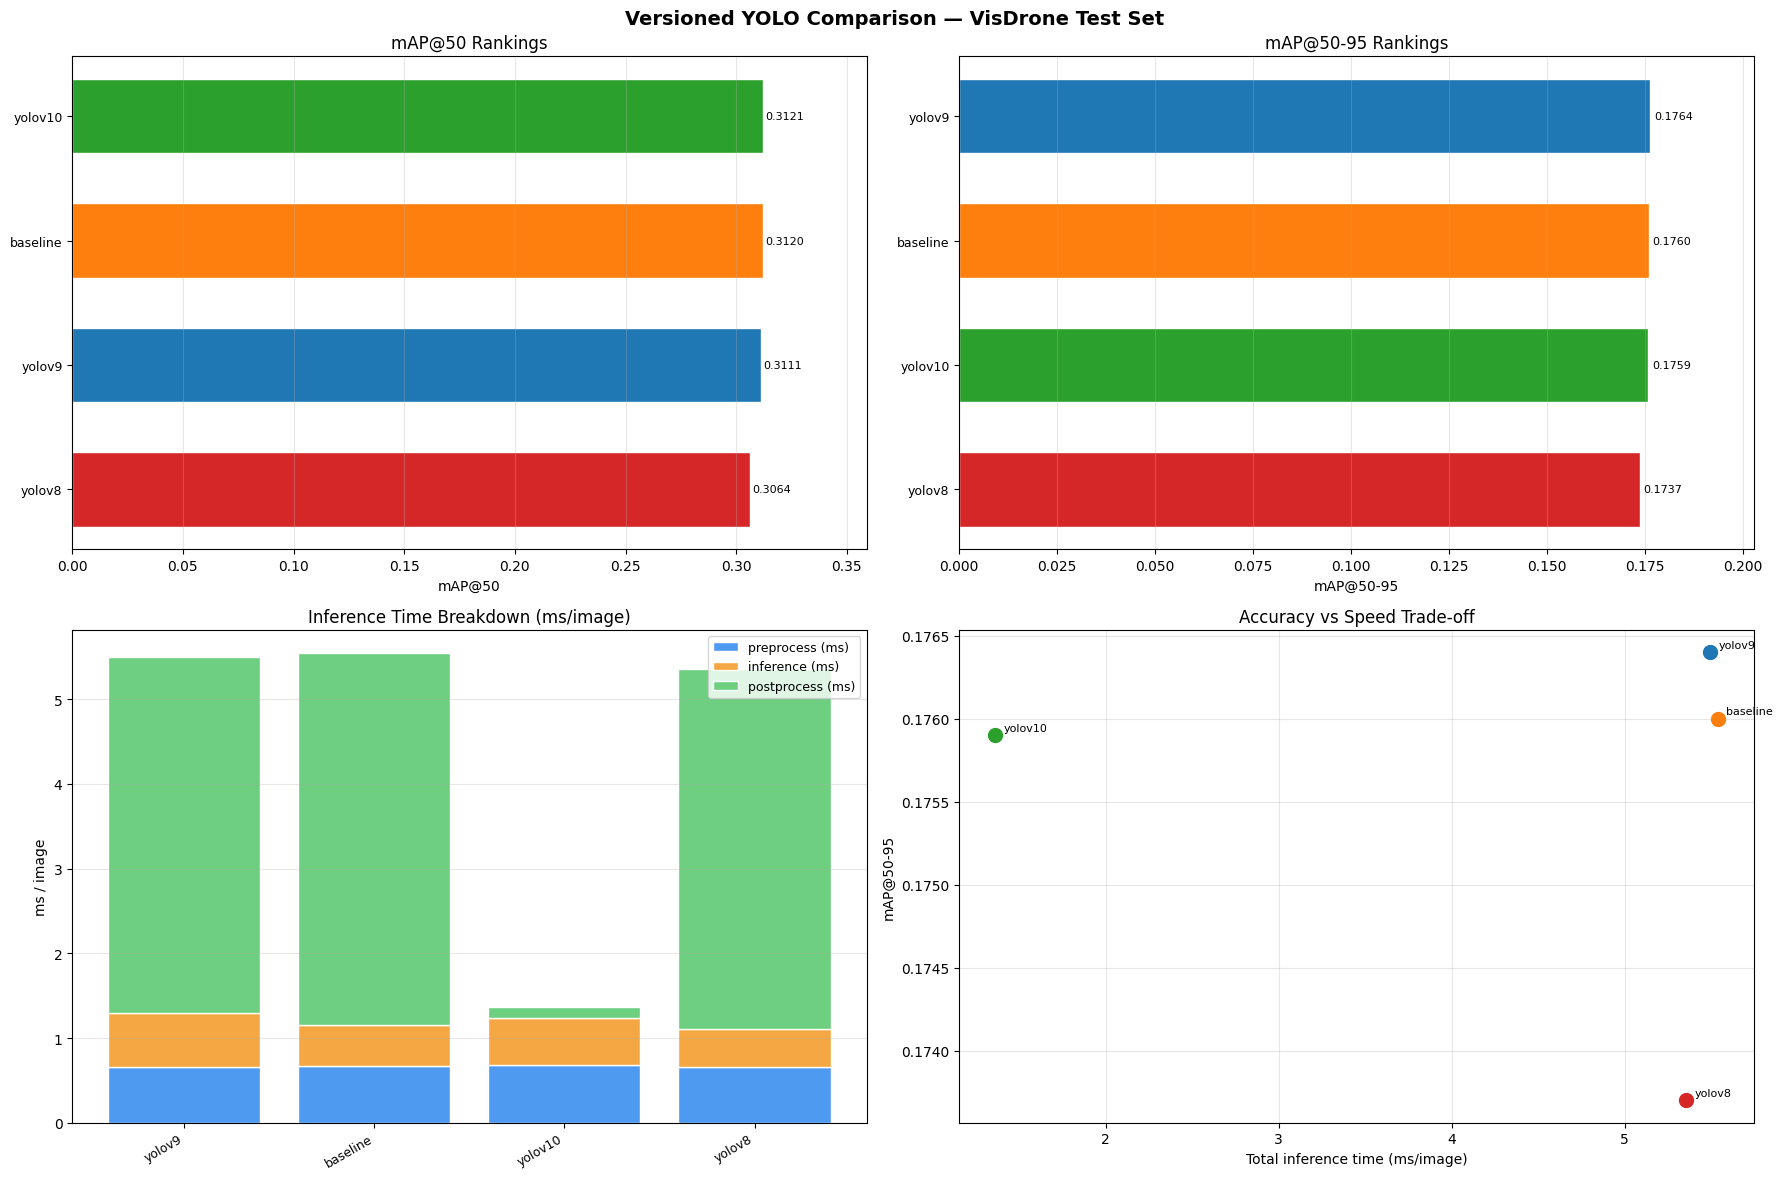

Saved → /content/rankings_versioned.png


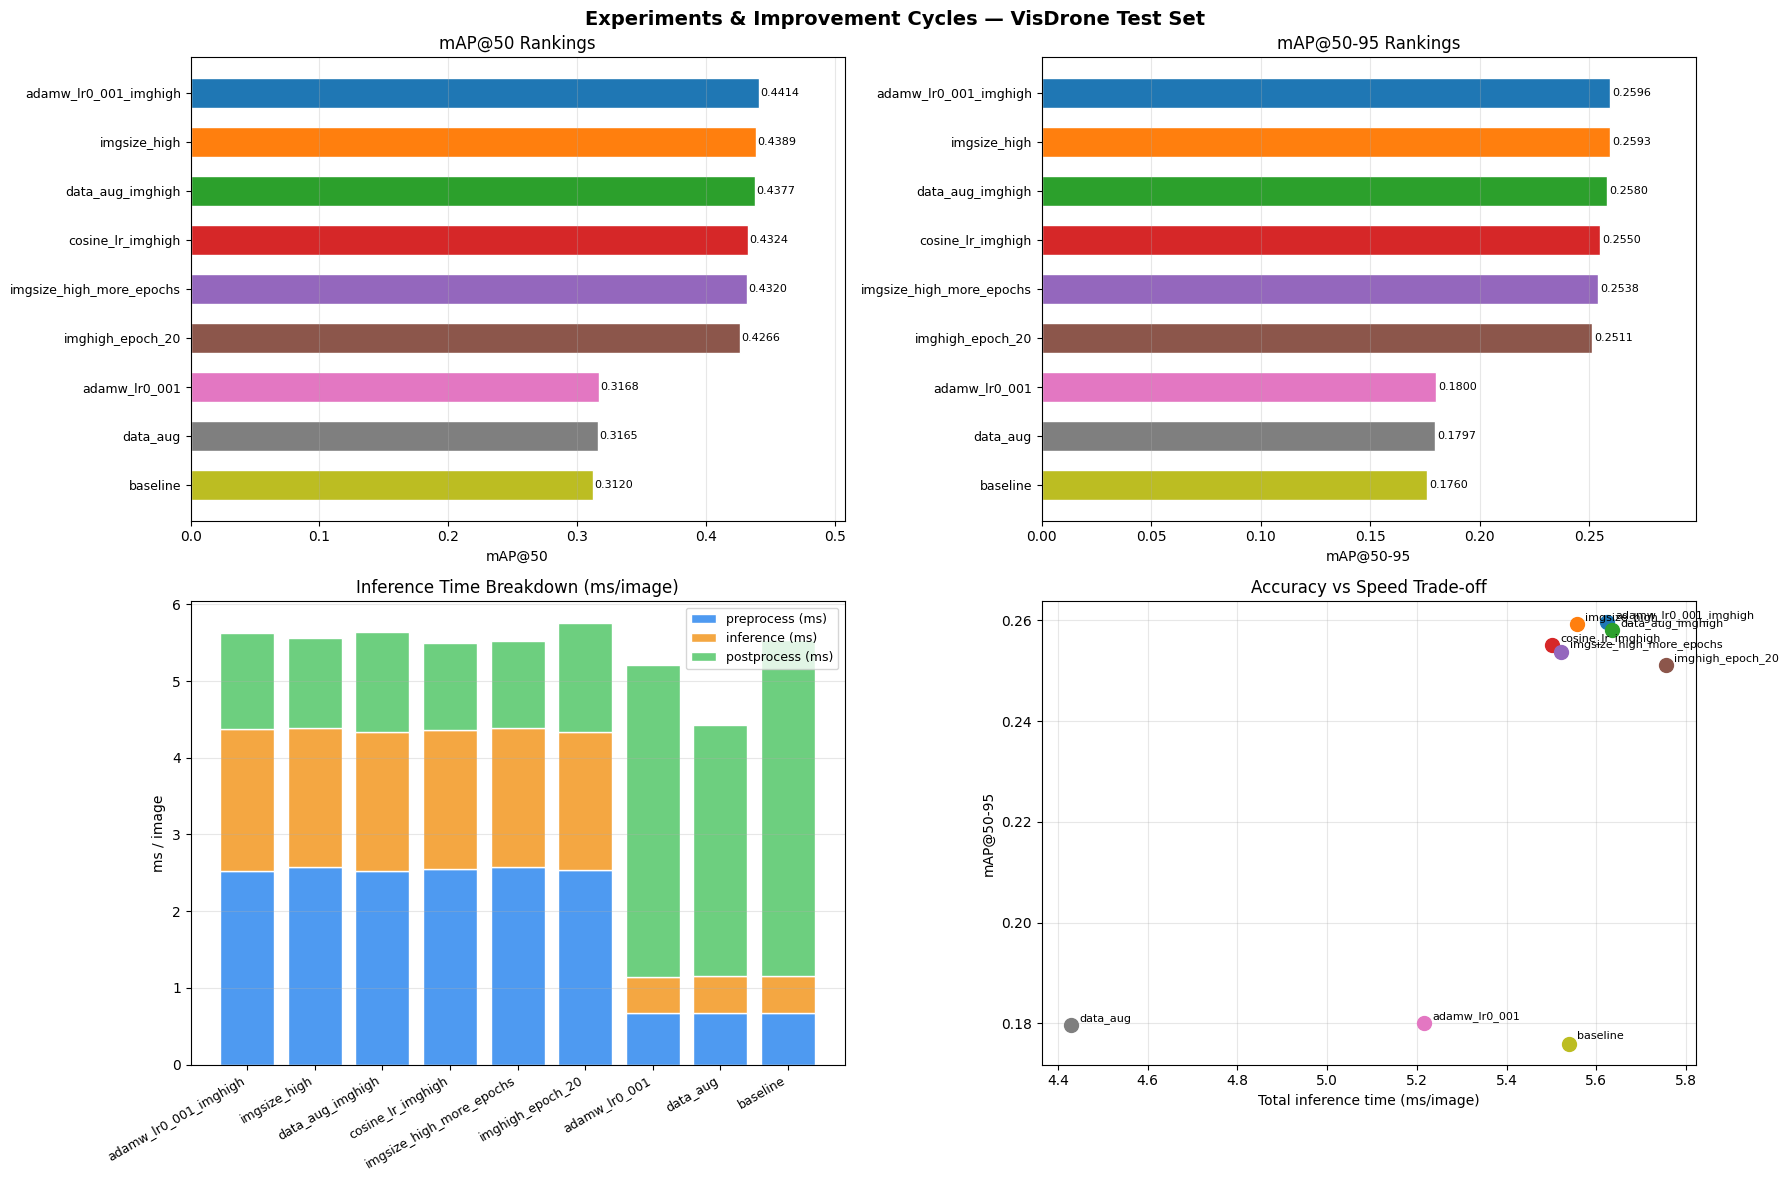

Saved → /content/rankings_experiments.png


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

def plot_model_rankings(df_full, exclude_models, title, out_filename):
    df = df_full[~df_full["model"].isin(exclude_models)].reset_index(drop=True)

    n_models  = len(df)
    x         = np.arange(n_models)

    base_colors = [cm.tab10(i / 10.0) for i in range(n_models)]
    color_map   = {model: base_colors[i] for i, model in enumerate(df["model"])}

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Top-left: mAP@50 ranking ──────────────────────────────────────────────
    ax = axes[0, 0]
    df_map50 = df.sort_values(by="mAP@50", ascending=True).reset_index(drop=True)
    y_pos_50 = np.arange(n_models)
    colors_50 = [color_map[m] for m in df_map50["model"]]
    ax.barh(y_pos_50, df_map50["mAP@50"], color=colors_50, edgecolor="white", height=0.6)
    ax.set_yticks(y_pos_50)
    ax.set_yticklabels(df_map50["model"], fontsize=9)
    ax.set_xlabel("mAP@50")
    ax.set_title("mAP@50 Rankings")
    ax.grid(axis="x", alpha=0.3)
    ax.set_xlim(0, max(df_map50["mAP@50"]) * 1.15)
    for val, pos in zip(df_map50["mAP@50"], y_pos_50):
        ax.text(val + 0.001, pos, f"{val:.4f}", va="center", fontsize=8)

    # ── Top-right: mAP@50-95 ranking ─────────────────────────────────────────
    ax2 = axes[0, 1]
    df_map95 = df.sort_values(by="mAP@50-95", ascending=True).reset_index(drop=True)
    y_pos_95 = np.arange(n_models)
    colors_95 = [color_map[m] for m in df_map95["model"]]
    ax2.barh(y_pos_95, df_map95["mAP@50-95"], color=colors_95, edgecolor="white", height=0.6)
    ax2.set_yticks(y_pos_95)
    ax2.set_yticklabels(df_map95["model"], fontsize=9)
    ax2.set_xlabel("mAP@50-95")
    ax2.set_title("mAP@50-95 Rankings")
    ax2.grid(axis="x", alpha=0.3)
    ax2.set_xlim(0, max(df_map95["mAP@50-95"]) * 1.15)
    for val, pos in zip(df_map95["mAP@50-95"], y_pos_95):
        ax2.text(val + 0.001, pos, f"{val:.4f}", va="center", fontsize=8)

    # ── Bottom-left: inference time breakdown ─────────────────────────────────
    ax3 = axes[1, 0]
    speed_cols   = ["preprocess (ms)", "inference (ms)", "postprocess (ms)"]
    speed_colors = ["#4e9af1", "#f4a742", "#6dcf7f"]
    bottoms = np.zeros(n_models)
    for col, color in zip(speed_cols, speed_colors):
        vals = df[col].values
        ax3.bar(x, vals, bottom=bottoms, label=col, color=color, edgecolor="white")
        bottoms += vals
    ax3.set_xticks(x)
    ax3.set_xticklabels(df["model"], rotation=30, ha="right", fontsize=9)
    ax3.set_ylabel("ms / image")
    ax3.set_title("Inference Time Breakdown (ms/image)")
    ax3.legend(fontsize=9)
    ax3.grid(axis="y", alpha=0.3)

    # ── Bottom-right: accuracy vs speed trade-off ─────────────────────────────
    ax4 = axes[1, 1]
    for _, row in df.iterrows():
        ax4.scatter(row["total_ms/img"], row["mAP@50-95"],
                    color=color_map[row["model"]], s=100, zorder=3)
        ax4.annotate(row["model"], (row["total_ms/img"], row["mAP@50-95"]),
                     textcoords="offset points", xytext=(6, 3), fontsize=8)
    ax4.set_xlabel("Total inference time (ms/image)")
    ax4.set_ylabel("mAP@50-95")
    ax4.set_title("Accuracy vs Speed Trade-off")
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = Path(out_filename)
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved → {out_path.resolve()}")
    plt.close()


# ── Run 1: Versioned comparison (baseline + yolov8/9/10, no experiments) ──────
EXCLUDE_EXPERIMENTS = [
    "adamw_lr0_001",
    "data_aug",
    "imgsize_high",
    "adamw_lr0_001_imghigh",
    "cosine_lr_imghigh",
    "imgsize_high_more_epochs",
    "imghigh_epoch_20",
    "data_aug_imghigh"
]
plot_model_rankings(
    df_full       = df,
    exclude_models= EXCLUDE_EXPERIMENTS,
    title         = "Versioned YOLO Comparison — VisDrone Test Set",
    out_filename  = "rankings_versioned.png",
)

# ── Run 2: Experiments + improvement cycles (baseline included, no versioned) ──
EXCLUDE_VERSIONED = ["yolov8", "yolov9", "yolov10"]
plot_model_rankings(
    df_full       = df,
    exclude_models= EXCLUDE_VERSIONED,
    title         = "Experiments & Improvement Cycles — VisDrone Test Set",
    out_filename  = "rankings_experiments.png",
)